# PyTorch Workflow
Let's explore a an example PyTorch end-toend workflow.

Resources:
* Ground truth notebook - 

In [1]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data(training )",
    4: "making prediction and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together",
}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data(training )',
 4: 'making prediction and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's buidling block for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.9.1+cpu'

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.
* Excel spreadsheet
* Images of any kind
* Videos (YouTube have a lot of data )
* Audio
* DNA
* TExt
Machine learning is a game of two part:
1. Get data into a numerical representaion.
2. Build a model to learn patterns in that numerical representation.
To showcase this, let's create some *know* data using the linear regression formula
We'll use a linear regression formula to make a straight line with know **paramater**


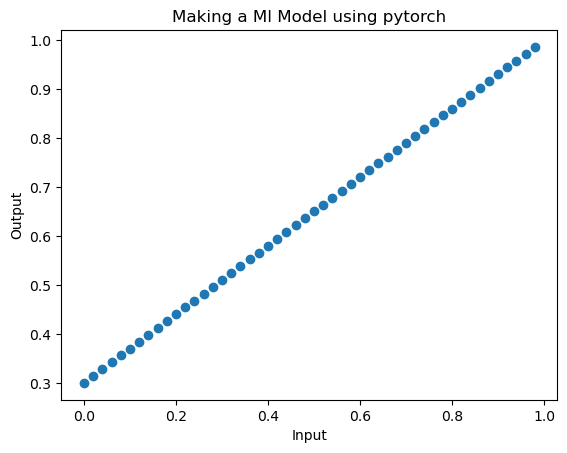

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460],
        [0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


In [3]:
# Create *know* paramater
weight = 0.7
bias = 0.3

### Formula of Linear Regression
# y = a + bx (a => bias) and (b = weight or gradient) 

########## Create ##########
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X+bias
plt.scatter(X,y)
plt.xlabel("Input")
plt.title("Making a Ml Model using pytorch")
plt.ylabel("Output")
plt.show()
print(y)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general )
Let's create a training and test set with our data.

In [4]:
# Create a train/test split
train_split = int(0.8*len(X))
X_train,Y_train = X[:train_split],y[:train_split]
X_test,Y_test = X[train_split:],y[train_split:]
len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

How might we better visualize our data?
This is where are data explorer's motto comes in!
"visualize,visualize,visualize" 

In [5]:
def plot_prediction(prediction=None):
    """PLots training data,test data and compaer predictions."""
    plt.figure(figsize=(10,7))
    plt.scatter(X_train,Y_train,c='b',s=15,label="Training Data") 
    plt.scatter(X_test,Y_test, c="g",s=15,label="Testing Data")
    if(prediction is not None):
        # Plot the prediction
        plt.scatter(X_test, prediction, c="r", s=15, label="Prediction Data")
    # Show the legend 
    plt.legend(prop={"size":14})

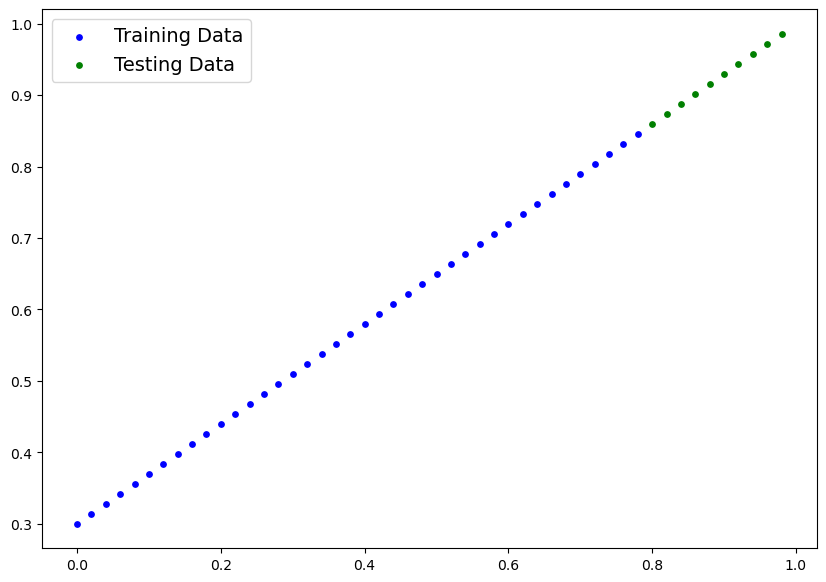

In [6]:
plot_prediction()

## 2. Build Model
Our first PyTorch model!
This is very exciting... let's do it!
What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random value to better represent (or get closer to) the ideal values ( the weight & bias values we used to create the data)
How does it do so? 
Through two main algorithms:
1. Gradient descent
2. Backpropogation

In [7]:
# Create linear regression model class
class LinearRegressionModel(
    nn.Module
):  # <- almost everthing in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.rand(1, requires_grad=True, dtype=torch.float)
        ) 

        self.bias = nn.Parameter(torch.rand(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
    def forward(self, X: torch.Tensor) -> torch.Tensor:  # <- "x" is the input data

        return self.weights * X + self.bias

### Checking the content of our PyTorch model 
Now we've created a model, let's see what's inside...
So we can check our model paramater  or what's inside our model using  `.parameters()`

In [8]:
# Create a random seed 
RANDOM_SEED = torch.manual_seed(42)

# Create an instance of the model ( this is the subclass of nn.Module)

model_0 = LinearRegressionModel()

# check out the paramater
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.8823], requires_grad=True), Parameter containing:
tensor([0.9150], requires_grad=True)]


In [9]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

### Making prediction using `torch.inference_mode()`
To check our model's predictive power, let's see how well it predicted `y_test` based on  `X_test`
When we pass data through our model, it's going to run it through the `forward()` method.

In [10]:
# Make predictions with model 
with torch.inference_mode():
    y_preds = model_0(X_test)  

# You can also do something similar with torch.no_grad(), however, inferrence_mode() is preferred
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [11]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

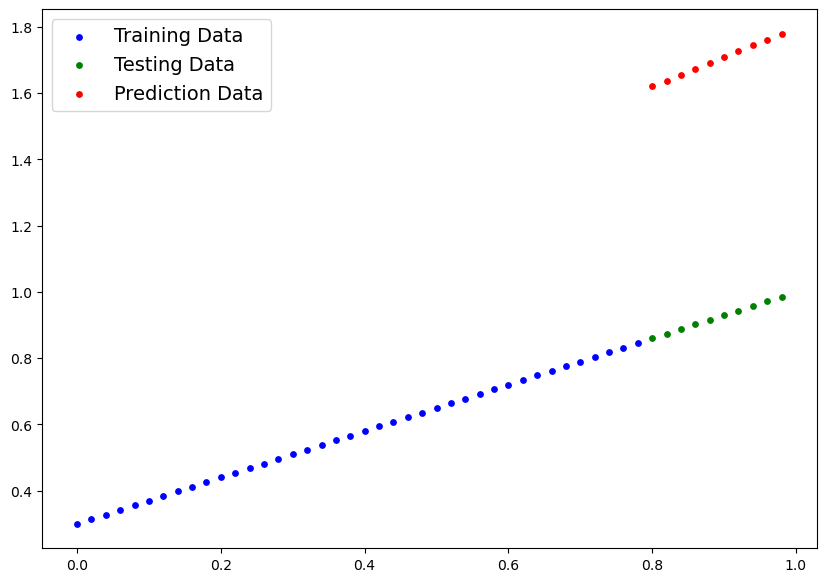

In [12]:
plot_prediction(prediction=y_preds)

## 3. Train model 
The whole idea of training is for a model to move from some *unknown* paramaters (these may be random) to some *known*
paramaters or in other words from a poor representation of the data to a better representation of the data.
One way to measure how poor or how wrong your models predictions are is to use a loss function.
* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:


* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:**  Takes into account the loss of a model  and adjusts the model's parameters (e.g. weight & bias) to improve the loss function.
And specifically for PyTorch, we need:
* A training loop
* Testing loop


In [13]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()



OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
# Setup a lost function (MAE Mean Absolute Error)
       
loss_fn = nn.L1Loss()


# Setups an optimizer (SGD Stochastic Gradient Descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),# parmas
                            lr=0.01, # lr = learning rate = possible the most hyperparameter you can set
                            momentum=0.9)
 

In [ ]:
loss_fn
torch.optim.SGD(y_preds,y)

L1Loss()